In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import pandas as pd
import re
import seaborn as sns
import itertools
import time
import sys
import os
import json
from IPython.display import display, Image, HTML
import warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath("."))
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# Load dataset

In [2]:
raw_data = pd.read_csv("Cars.csv")
raw_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.000000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.000000
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.000000
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.000000
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.000000


# Data pre-processing used in A1

In [3]:
X = raw_data.drop(['selling_price'], axis=1).copy()
y = raw_data['selling_price'].copy()

In [4]:
cat_cols = [i for i in X.columns if X[i].dtype == np.object_]
num_cols = [i for i in X.columns if X[i].dtype != np.object_]

In [5]:
# striping extra spaces
X[cat_cols] = X[cat_cols].apply(lambda col: col.str.strip())
# removing string from mileage,	engine,	max_power
# pattern = re.compile(r"\d+(?:\.\d+)?")
# X["mileage"] = [float(re.findall(pattern, i)[0]) if pd.notna(i) else i for i in X['mileage'].values]
# X["engine"] = [float(re.findall(pattern, i)[0]) if pd.notna(i) else i for i in X['engine'].values]
# X["max_power"] = X['max_power'].str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)

X["mileage"] = (
    X["mileage"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

X["engine"] = (
    X["engine"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

X["max_power"] = (
    X["max_power"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

In [6]:
"""For the feature fuel, remove all rows with CNG and
LPG because CNG and LPG use a different
mileage system i.e., km/kg which is different
from kmfeaturepl for Diesel and Petrol"""

mask = (X['fuel'] == 'CNG')  | (X['fuel'] == 'LPG')
index = X[mask].index
assert bool((y.iloc[index].index == X.iloc[index,:].index).all()), "x and y index not same"

X = X.drop(index)
y = y.drop(index)

In [7]:
# taking brand name from name
X.loc[:, "name"] = [i[0] if len(i) > 1 else np.nan for i in X['name'].str.split(' ')]
X.rename(columns={"name":"brand"}, inplace=True)

In [8]:
# Dropping torque column
X = X.drop("torque", axis=1)

In [9]:
# dropping rows related
mask = (X['fuel'] == 'CNG')  | (X['fuel'] == 'LPG')
index = X[mask].index
assert bool((y.iloc[index].index == X.iloc[index,:].index).all()), "x and y index not same"

X = X.drop(index)
y = y.drop(index)

In [10]:
# Dropping Test Drive Car as they have hude value and expensive
index = X[X['owner'] == 'Test Drive Car'].index
print(np.median(y[index]) > np.median(y.drop(index)))
X = X.drop(index)
y = y.drop(index)

True


In [11]:
# changing the data type
X[['mileage', 'engine', 'max_power']] = X[['mileage', 'engine', 'max_power']].astype(float)

In [12]:
num_cols = [i for i in X.columns if X[i].dtype is not np.object_]
cat_cols = [i for i in X.columns if X[i].dtype == np.object_]

In [13]:
# lower the text data to avoid uppercase and lowercase issue of same data
X[cat_cols] = X[cat_cols].apply(lambda x:x.str.lower())

In [14]:
# check null values
X.isnull().sum()

brand             0
year              0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage         214
engine          214
max_power       208
seats           214
dtype: int64

In [15]:
mask_all_null = X[['mileage','engine','max_power','seats']].isna().all(axis=1)
indx = X[mask_all_null].index
X = X.drop(indx)
y = y.drop(indx)

In [16]:
X.isnull().sum()

brand           0
year            0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         6
engine          6
max_power       0
seats           6
dtype: int64

In [17]:
# total duplicates
print(X.duplicated().sum())
index = [*X[X.duplicated()].index]
X = X.drop(index)
y = y.drop(index)

1675


In [18]:
# applying log to dependent variable, as
y_log = np.log(y)

## Data split

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, y_log_train, y_log_test = train_test_split(
    X, y, y_log, test_size=0.20, random_state=42
)

# Experimentation of Linear model with different setup

In [20]:
# fixed seed for Experimentation and Best model training
RNG = np.random.default_rng(42)

In [21]:
regression_types = ["normal", "lasso", "ridge", "polynomial"]
momentum_options = [False, True]
methods = ["sto", "mini", "batch"]
init_methods = ["zeros", "xavier"]
learning_rates = [0.01, 0.001, 0.0001]

In [ ]:
from Models import *
from Utils import *

db_path = os.path.join(
    os.getcwd(), "exps", "exp_train", "mlflow4.db"
)
tracking_uri = f"sqlite:///{db_path.replace(os.sep, '/')}"
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("A2-Car-Price-Experiment-v1")

combos = list(
    itertools.product(
        regression_types, momentum_options, methods, init_methods, learning_rates
    )
)
total_combos = len(combos)
print(f"Total combinations to run: {total_combos}")

results = []
start_time = time.time()

for i, (reg_type, use_momm, method, init_m, lr) in enumerate(combos, start=1):
    use_poly = (reg_type == "polynomial")

    if reg_type == "lasso":
        ModelCls, kwargs = LassoLinearRegression, {"l": 0.1}
    elif reg_type == "ridge":
        ModelCls, kwargs = RidgeLinearRegression, {"l": 0.1}
    else:
        ModelCls, kwargs = NormalLinearRegression, {}  # covers "normal" and "polynomial"

    run_name = f"{reg_type}_mom{use_momm}_{method}_{init_m}_lr{lr}"

    combo_start = time.time()
    print(f"[{i}/{total_combos}] Running: {run_name} ...", end=" ", flush=True)

    with mlflow.start_run(run_name=run_name) as parent_run:
        mlflow.log_params(
            {
                "regression_type": reg_type,
                "use_momentum": use_momm,
                "method": method,
                "init_method": init_m,
                "learning_rate": lr,
            }
        )

        model = ModelCls(
            lr=lr,
            method=method,
            num_epochs=30,
            batch_size=64,
            n_splits=5,
            init_method=init_m,
            momentum=0.9 if use_momm else 0.0,
            use_momentum=use_momm,
            rng=RNG,
            **kwargs,
        )
        model.fit(X_train, y_log_train.values,use_poly=use_poly, idx_=4)

        avg_val_mse = np.mean(model.kfold_scores)
        avg_val_r2 = np.mean(model.kfold_r2_scores)
        mlflow.log_metric("avg_kfold_val_mse", avg_val_mse)

        results.append(
            {
                "regression_type": reg_type,
                "momentum": use_momm,
                "method": method,
                "init": init_m,
                "lr": lr,
                "avg_val_mse": avg_val_mse,
                "avg_val_r2": avg_val_r2,
                "mlflow_run_id": parent_run.info.run_id
            }
        )

    combo_time = time.time() - combo_start
    elapsed = time.time() - start_time
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (total_combos - i)
    print(
        f"done in {combo_time:.1f}s | avg_val_mse={avg_val_mse:.4f} | "
        f"elapsed={elapsed/60:.1f}min | est. remaining={remaining/60:.1f}min"
    )

results_df = pd.DataFrame(results)

In [ ]:
results_df_sorted = results_df.sort_values(by="avg_val_mse", ascending=True)
results_df_sorted.head(10)

In [ ]:
res_save_folder = os.path.join(os.getcwd(), "results_folder")
os.makedirs(res_save_folder, exist_ok=True)
results_df.to_csv(os.path.join(res_save_folder, 'results4.csv'))

In [ ]:
# to retrive best model's saved transformation .pkl for further use
from mlflow.tracking import MlflowClient

db_path = os.path.join(
    os.getcwd(), "exps", "exp_train", "mlflow4.db"
)
tracking_uri = f"sqlite:///{db_path.replace(os.sep, '/')}"
mlflow.set_tracking_uri(tracking_uri)
client = MlflowClient()

base_dir = os.path.join("saved_models", "fold_pipelines4")
folder_ids = os.listdir(base_dir) 

rows = []
for run_id in folder_ids:
    try:
        fold_run = client.get_run(run_id)
    except mlflow.exceptions.MlflowException:
        rows.append({"folder": run_id, "status": "no matching run in mlflow.db"})
        continue

    parent_id = fold_run.data.tags.get("mlflow.parentRunId")
    parent = client.get_run(parent_id) if parent_id else None

    rows.append({
        "folder": run_id,
        "fold_run_name": fold_run.info.run_name,    
        "fold_index": fold_run.data.params.get("fold"),
        "parent_run_id": parent_id,
        "combo_name": parent.info.run_name if parent else None,
        "regression_type": parent.data.params.get("regression_type") if parent else None,
        "method": parent.data.params.get("method") if parent else None,
        "learning_rate": parent.data.params.get("learning_rate") if parent else None,
        "init_method": parent.data.params.get("init_method") if parent else None,
        "use_momentum": parent.data.params.get("use_momentum") if parent else None
    })

mapping_df = pd.DataFrame(rows)
merged = results_df.merge(
    mapping_df, left_on='mlflow_run_id', right_on='parent_run_id', how='left'
)
best_combo_folds = merged[merged['mlflow_run_id'] == results_df.sort_values('avg_val_mse').iloc[0]['mlflow_run_id']]
merged.to_csv(os.path.join(res_save_folder, 'merged4.csv'))
best_combo_folds.to_csv(os.path.join(res_save_folder, 'best_combo_folds4.csv'))

## Experiments evaluation

In [22]:
results_df = pd.read_csv(r'results_folder/results4.csv')
results_df = results_df.drop("Unnamed: 0",axis=1)

merged_df = pd.read_csv(r'results_folder/merged4.csv')
merged_df = merged_df.drop("Unnamed: 0",axis=1)

In [26]:
top_10_exp = results_df.sort_values(by = "avg_val_mse", ascending=True).head(10)
top_10_exp

,regression_type,momentum,method,init,lr,avg_val_mse,avg_val_r2,mlflow_run_id
113,polynomial,False,sto,xavier,0.000100,0.076117,0.868088,7056641acfbc42688c9fec3e5b29c5cc
110,polynomial,False,sto,zeros,0.000100,0.076205,0.867929,7bfc2d36e6e04133ab80c58a387bf977
130,polynomial,True,sto,xavier,0.001000,0.076236,0.867884,a9d27a46406e4c2bac26d46d17756a32
127,polynomial,True,sto,zeros,0.001000,0.076260,0.867834,6f51d7fd37b64bd9baa112b84c1c92ce
117,polynomial,False,mini,xavier,0.010000,0.076390,0.867619,601f823ecb7f449d82b5a22f08aff8ed
114,polynomial,False,mini,zeros,0.010000,0.076880,0.866769,7aa2e1b2c11744688f6e56d8f53bf576
21,normal,True,sto,xavier,0.010000,0.085516,0.851588,915d750b410f47f4b2b3f3fdee813c43
1,normal,False,sto,zeros,0.001000,0.086216,0.850427,ac297b6535ba4d5fa8a001f3f1c6f7c6
18,normal,True,sto,zeros,0.010000,0.086721,0.849562,ff2d832a2ece4ed0a30df0ee9ea410a1
4,normal,False,sto,xavier,0.001000,0.086795,0.849386,ee483f86d7214c62bca70207a029eec6


In [28]:
top10 = top_10_exp.iloc[:,:]
top10["model"] = (
    top10["regression_type"] + "_" +
    top10["momentum"].astype(str) + "_" +
    top10["method"] + "_" +
    top10["init"] + "_" +
    top10["lr"].astype(str)
)

<b>Top 10 Models by Validation MSE</b>

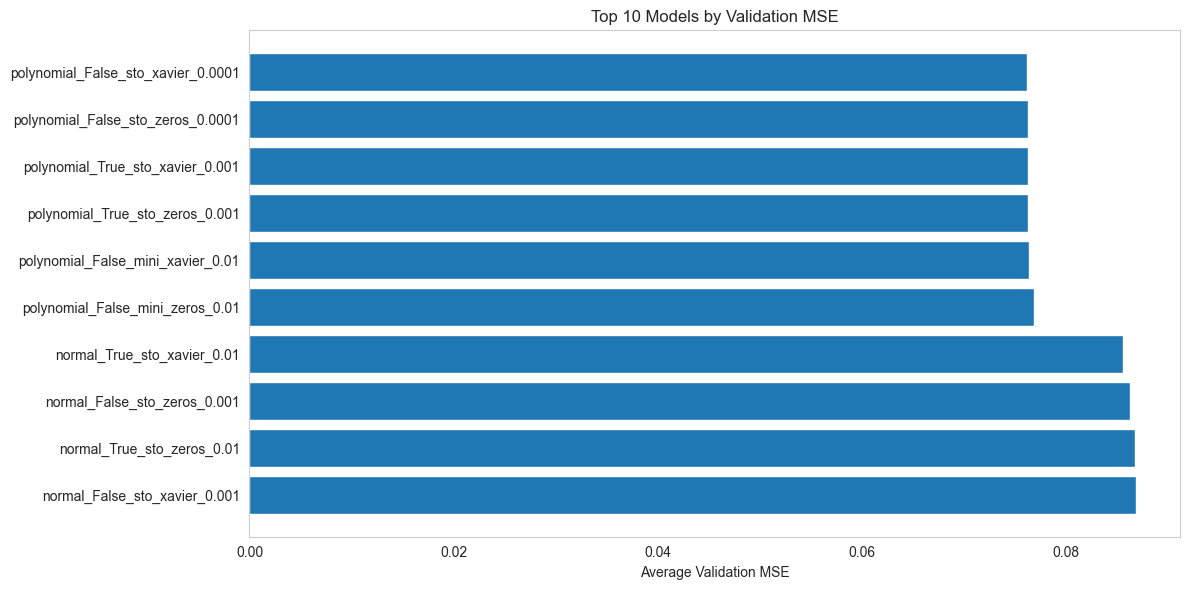

In [76]:
temp = top10.sort_values('avg_val_mse', ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(temp["model"], temp["avg_val_mse"])
plt.xlabel("Average Validation MSE")
plt.title("Top 10 Models by Validation MSE")
plt.tight_layout()
plt.grid(False)
plt.show()

The best configuration is **`polynomial_False_sto_xavier_0.0001`**, closely followed by five other polynomial setups using mini-batch or stochastic gradient descent. Normal regression models fill the remaining top ten spots (**`normal_False_sto_xavier_0.001`** to **`normal_True_sto_zeros_0.01`**). Polynomial models consistently outperformed normal models, while momentum and initialization methods showed negligible performance differences.

<b>Top 10 Models by Validation R²</b>

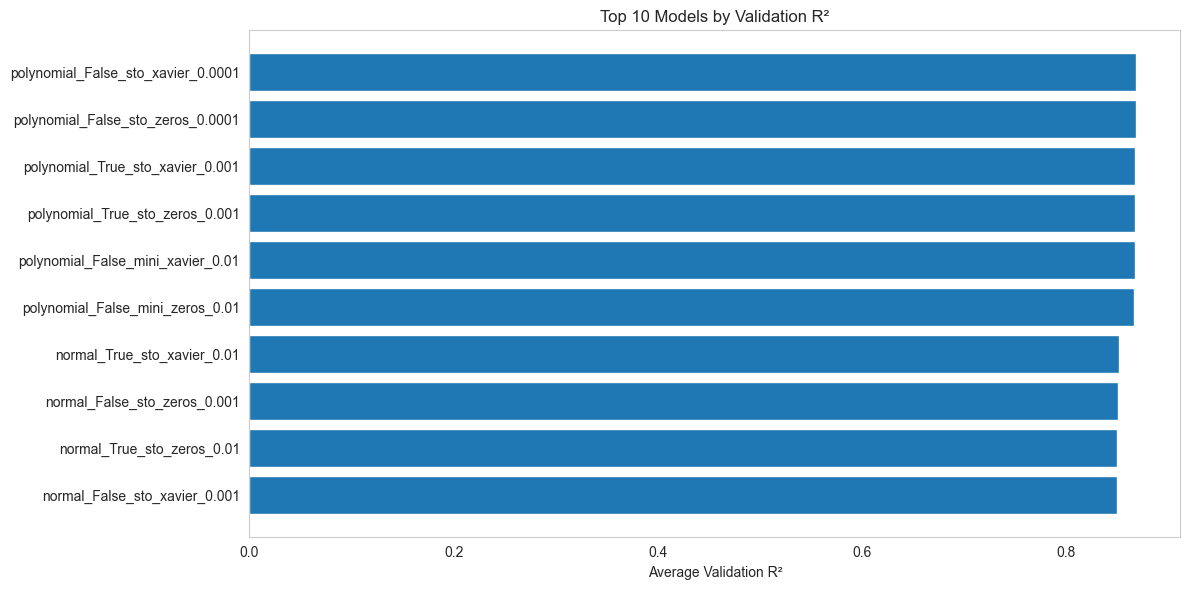

In [77]:
top10_r2 = top10.sort_values("avg_val_r2", ascending=False).head(10)
temp1 = top10_r2.sort_values("avg_val_r2", ascending=True) 
plt.figure(figsize=(12, 6))
plt.barh(temp1["model"], temp1["avg_val_r2"])
plt.xlabel("Average Validation R²")
plt.title("Top 10 Models by Validation R²")
plt.tight_layout()
plt.grid(False)
plt.show()

The top configuration by Average Validation $R^2$ is **`polynomial_False_sto_xavier_0.0001`**, followed by five other polynomial setups using mini-batch or stochastic descent. Normal regression models fill the bottom four spots (**`normal_False_sto_xavier_0.001`** through **`normal_True_sto_zeros_0.01`**). Polynomial models consistently achieved higher $R^2$ scores, while momentum and initialization options showed minimal impact.

<b>Divergence Rate by Learning Rate</b>

In [56]:
from mlflow.tracking import MlflowClient
db_path = os.path.join(
    os.getcwd(), "exps", "exp_train", "mlflow4.db"
)
tracking_uri = f"sqlite:///{db_path.replace(os.sep, '/')}"
mlflow.set_tracking_uri(tracking_uri)
client = MlflowClient()


experiment_id = "1"
runs = mlflow.search_runs(experiment_ids=[experiment_id])
parents = runs[runs["tags.mlflow.parentRunId"].isna()].copy()
children = runs[runs["tags.mlflow.parentRunId"].notna()].copy()

children["diverged"] = (
    (children["metrics.val_loss"] > 1e10) |
    children["metrics.val_loss"].isna() |
    np.isinf(children["metrics.val_loss"])
)

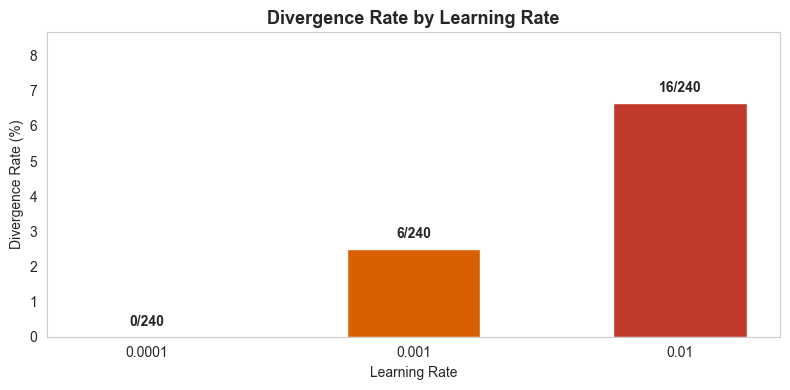

In [78]:
divergence_by_lr = children.groupby("params.lr")["diverged"].agg(["sum", "count"])
divergence_by_lr["rate"] = divergence_by_lr["sum"] / divergence_by_lr["count"]

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(
    divergence_by_lr.index.astype(str),
    divergence_by_lr["rate"] * 100,
    color=["#2b5c8f", "#d95f02", "#c0392b"],
    width=0.5,
)

for bar, (idx, row) in zip(bars, divergence_by_lr.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{int(row['sum'])}/{int(row['count'])}",
        ha="center", fontsize=10, fontweight="bold"
    )

ax.set_xlabel("Learning Rate")
ax.set_ylabel("Divergence Rate (%)")
ax.set_title("Divergence Rate by Learning Rate", fontweight="bold", fontsize=13)
ax.set_ylim(0, max(divergence_by_lr["rate"] * 100) * 1.3)
plt.tight_layout()
plt.grid(False)
plt.show()

Higher learning rates cause more training failures. At 0.0001, no runs diverged. At 0.001, 6 out of 240 failed. At 0.01, 16 out of 240 failed — over 6%. Larger learning rates make weight updates too big, causing the model to overshoot and blow up.

<b>MLflow Run List (sorted by avg_kfold_val_mse)</b>

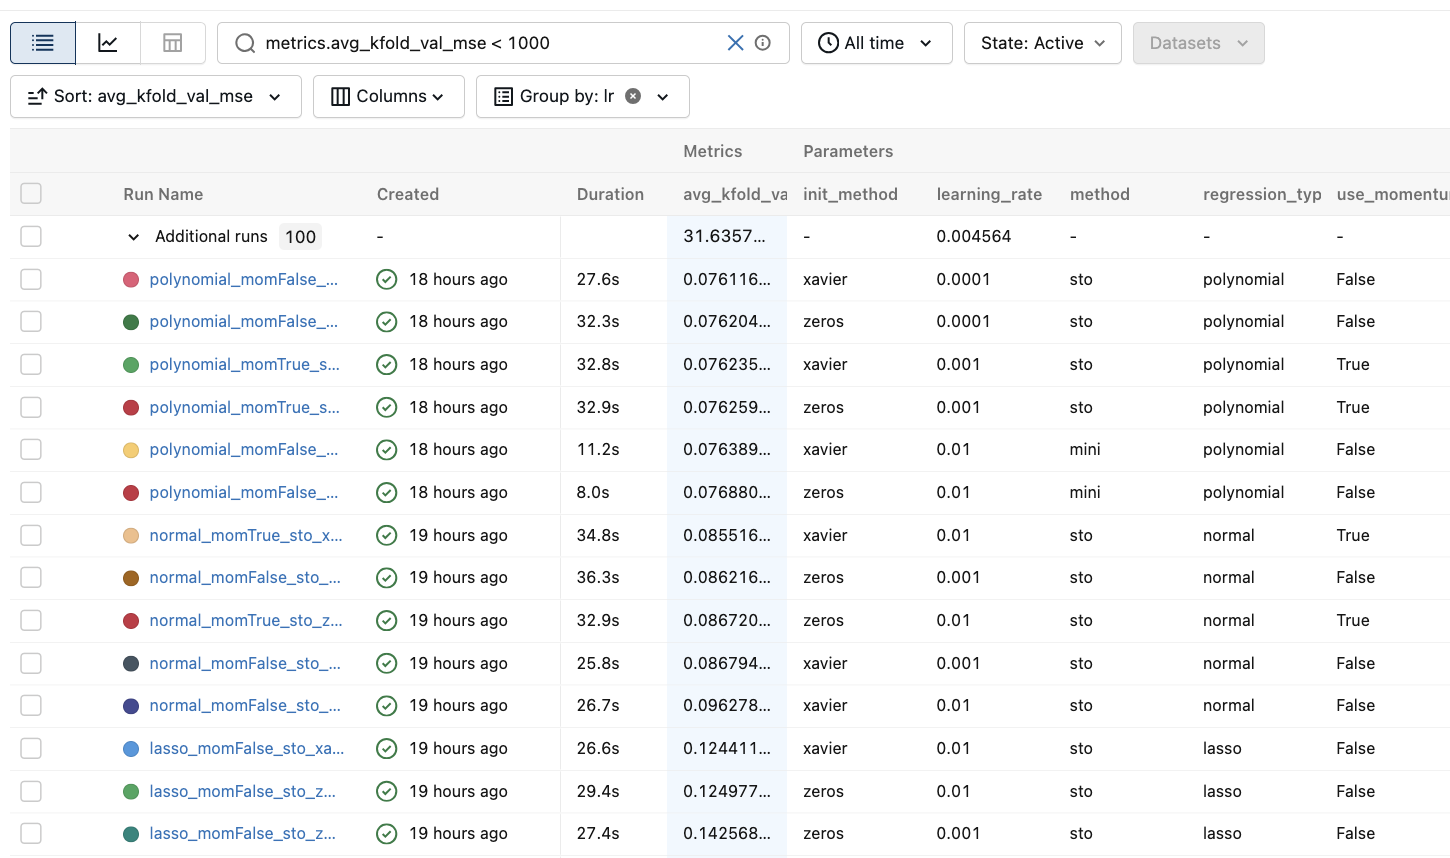

In [ ]:
display(Image(filename=r'images/A4.png', height=1000, width=1000))

This table ranks all 144 experiments by validation MSE, best first. Polynomial regression with stochastic gradient descent dominates the top, showing lower error and outperforming normal, lasso, and ridge configurations.

<b>Effect of Regularization Type on Validation MSE</b>

In [88]:
display(HTML("""
<div style="display: flex; gap: 20px;">

    <div style="text-align: center;">
        <h3>Excluding Ridge (MSE < 0.2)</h3>
        <img src="images/less than 0.2.png" width="700" height="400">
        <h3>Image 1</h3>
    </div>

    <div style="text-align: center;">
        <h3>Including Ridge (MSE < 2)</h3>
        <img src="images/less than 2.png" width="700" height="400">
        <h3>Image 2</h3>
    </div>

</div>
"""))

These two parallel coordinates plots reveal a key finding: Ridge regularization performs dramatically worse than the other regression types. Image 1 (MSE < 0.2, excluding Ridge) shows Polynomial, Normal, and Lasso clustered tightly between 0.076–0.15, with learning rate as the dominant driver — lr=0.0001 consistently produces the best (dark blue) results, while lr=0.01 produces the worst (red). Image 2 (MSE < 2, including Ridge) reveals Ridge configurations reaching MSE values up to ~1.98, over 10x worse than any other type. This suggests Ridge's default regularization strength over-penalized coefficients, substantially degrading predictive performance compared to Lasso and unregularized alternatives.

<b>Validation R² by Method</b>

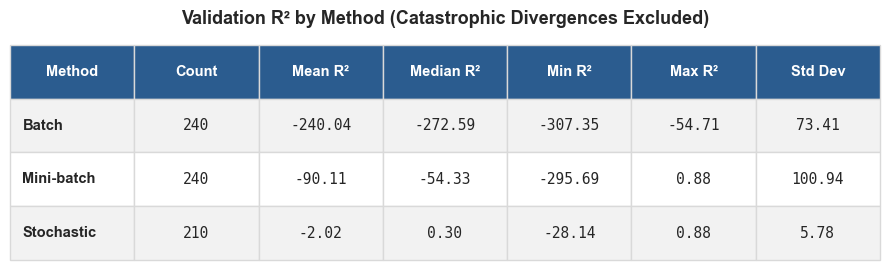

In [ ]:
converged = children[
    ~children["diverged"] &
    children["metrics.val_r2"].notna() &
    (children["metrics.val_r2"] > -1000)  
]


# summary table from the filtered (catastrophic-outlier-excluded) data
summary = converged.groupby("params.method")["metrics.val_r2"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max",
    std="std"
).round(3)

summary = summary.reindex(["batch", "mini", "sto"])  # logical order
summary.columns = ["Count", "Mean R²", "Median R²", "Min R²", "Max R²", "Std Dev"]


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")

col_labels = ["Method", "Count", "Mean R²", "Median R²", "Min R²", "Max R²", "Std Dev"]
row_data = [
    ["Batch", "240", f"{summary.loc['batch', 'Mean R²']:.2f}", f"{summary.loc['batch', 'Median R²']:.2f}",
     f"{summary.loc['batch', 'Min R²']:.2f}", f"{summary.loc['batch', 'Max R²']:.2f}", f"{summary.loc['batch', 'Std Dev']:.2f}"],
    ["Mini-batch", "240", f"{summary.loc['mini', 'Mean R²']:.2f}", f"{summary.loc['mini', 'Median R²']:.2f}",
     f"{summary.loc['mini', 'Min R²']:.2f}", f"{summary.loc['mini', 'Max R²']:.2f}", f"{summary.loc['mini', 'Std Dev']:.2f}"],
    ["Stochastic", str(summary.loc['sto', 'Count']), f"{summary.loc['sto', 'Mean R²']:.2f}", f"{summary.loc['sto', 'Median R²']:.2f}",
     f"{summary.loc['sto', 'Min R²']:.2f}", f"{summary.loc['sto', 'Max R²']:.2f}", f"{summary.loc['sto', 'Std Dev']:.2f}"],
]

table = ax.table(cellText=row_data, colLabels=col_labels, cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10.5)

header_color = "#2b5c8f"
row_colors = ["#f2f2f2", "#ffffff"]

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#d9d9d9")
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_height(0.2)
    else:
        cell.set_facecolor(row_colors[(row - 1) % 2])
        cell.set_height(0.2)
        if col == 0:
            cell.set_text_props(fontweight="bold", ha="left")
        else:
            cell.set_text_props(fontfamily="monospace")

ax.set_title("Validation R² by Method (Catastrophic Divergences Excluded)", fontweight="bold", fontsize=13, pad=15)
plt.tight_layout()
plt.show()


Full-batch gradient descent failed to achieve positive validation R² in any of its 240 fold-runs (mean -240.04, range -307.35 to -54.71), and mini-batch performed poorly in the majority of cases (median R² = -54.33), while stochastic gradient descent was the only method that reliably reached strong fits (median R² = 0.30, max 0.88). This is consistent with our earlier finding that update frequency per epoch is a major factor in this experiment: with a fixed epoch budget, full-batch gradient descent receives only one parameter update per epoch, compared to potentially thousands for stochastic descent, leaving it unable to converge meaningfully within the same training budget.

# Train best model

In [97]:
# load saved transformations from .pkl files
bestModelMLflowId = top_10_exp.iloc[0]['mlflow_run_id']
best_fold_folder_name = merged_df[merged_df['mlflow_run_id'] == bestModelMLflowId].sort_values(by="avg_val_mse", ascending=True)
n = best_fold_folder_name.iloc[0]['folder']
path = os.path.join(os.getcwd(), "saved_models", "fold_pipelines4", n)
val = [os.path.join(path,i) for i in os.listdir(path)]
keys = [i.split(os.sep)[-1].split('.')[0] for i in val]
trans_data = {k:v for k,v in zip(keys,val)}
trans_data

{'sk': '/Users/imtiaz/Documents/mlass2/mlass2n/A2 - Predicting Car Prices/saved_models/fold_pipelines4/81b84d6e04a24f1c86e365457f023bd1/sk.pkl',
 'poly': '/Users/imtiaz/Documents/mlass2/mlass2n/A2 - Predicting Car Prices/saved_models/fold_pipelines4/81b84d6e04a24f1c86e365457f023bd1/poly.pkl',
 'ct': '/Users/imtiaz/Documents/mlass2/mlass2n/A2 - Predicting Car Prices/saved_models/fold_pipelines4/81b84d6e04a24f1c86e365457f023bd1/ct.pkl'}

In [98]:
from Models import *
from Utils import *

best_row = best_fold_folder_name.iloc[0]
print("Best combo:", best_row.to_dict())

# load transformers
ct_trans = joblib.load(trans_data["ct"])
sk_trans = joblib.load(trans_data["sk"])
poly_trans = joblib.load(trans_data["poly"])

X_train_tr = ct_trans.transform(X_train)
X_train_tr = sk_trans.transform(X_train_tr)

X_train_tr_poly = poly_trans.transform(X_train_tr)

Best combo: {'regression_type_x': 'polynomial', 'momentum': False, 'method_x': 'sto', 'init': 'xavier', 'lr': 0.0001, 'avg_val_mse': 0.076116553310284, 'avg_val_r2': 0.868088499815028, 'mlflow_run_id': '7056641acfbc42688c9fec3e5b29c5cc', 'folder': '81b84d6e04a24f1c86e365457f023bd1', 'fold_run_name': 'Fold-3', 'fold_index': nan, 'parent_run_id': '7056641acfbc42688c9fec3e5b29c5cc', 'combo_name': 'polynomial_momFalse_sto_xavier_lr0.0001', 'regression_type_y': 'polynomial', 'method_y': 'sto', 'learning_rate': 0.0001, 'init_method': 'xavier', 'use_momentum': False}


In [ ]:

db_path = os.path.join(os.getcwd(), "exps", "best_model_train", "mlflow4.db")
tracking_uri = f"sqlite:///{db_path.replace(os.sep, '/')}"
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("A2-Car-Price-Experiment-v1")

ModelCls_map = {
    "normal": NormalLinearRegression,
    "polynomial": NormalLinearRegression,
    "lasso": LassoLinearRegression,
    "ridge": RidgeLinearRegression,
}
X_train_data_map = {
    "normal": X_train_tr,
    "lasso": X_train_tr,
    "ridge": X_train_tr,
    "polynomial": X_train_tr_poly,
}
kwargs_map = {"normal": {}, "polynomial": {}, "lasso": {"l": 0.1}, "ridge": {"l": 0.1}}
reg_type = best_row["regression_type_x"]

up = reg_type == "polynomial"

best_model = ModelCls_map[reg_type](
    lr=best_row["lr"],
    method=best_row["method_x"],
    num_epochs=30,  # same as experiment
    batch_size=64,  # same as experiment
    n_splits=5,  # same as experiment
    init_method=best_row["init"],
    momentum=0.9 if best_row["momentum"] else 0.0,
    use_momentum=bool(best_row["momentum"]),
    rng = RNG,
    **kwargs_map[reg_type],
)
results = best_model.fit_final(
    X_train_data_map[reg_type],
    y_log_train.values,
    save_weight=True,
    model_name=reg_type,
    idx_=4,
    use_poly=up
)

<b>Best Model train Evaluation: MSE, RMSE and R² across Scales</b>

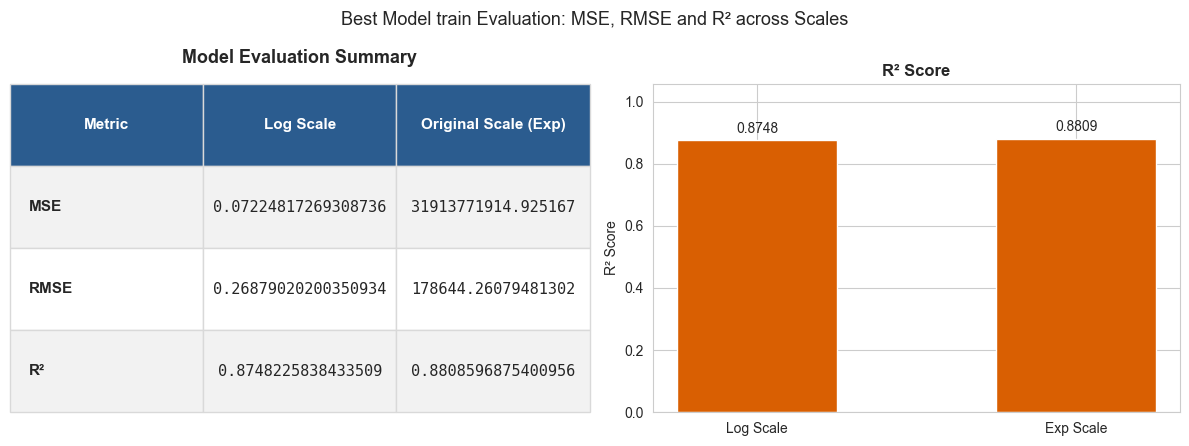

In [95]:
with open(r"saved_models/best_model_results4.json", "r") as f:
    metrics_data = json.load(f)[0]

mse_log = metrics_data["mse_log"]
mse_exp = metrics_data["mse_exp"]
r2_log = metrics_data["r2_log"]
r2_exp = metrics_data["r2_exp"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.1, 1]})

ax_table = axes[0]
ax_table.axis("off")

col_labels = ["Metric", "Log Scale", "Original Scale (Exp)"]
row_data = [
    ["MSE",  f"{mse_log}",        f"{mse_exp}"],
    ["RMSE", f"{np.sqrt(mse_log)}", f"{np.sqrt(mse_exp)}"],
    ["R²",   f"{r2_log}",          f"{r2_exp}"],
]

table = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)

table.auto_set_font_size(False)
table.set_fontsize(11)

header_color = "#2b5c8f"
row_colors = ["#f2f2f2", "#ffffff"]

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#d9d9d9")
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_height(0.18)
    else:
        cell.set_facecolor(row_colors[(row - 1) % 2])
        cell.set_height(0.18)
        if col == 0:
            cell.set_text_props(fontweight="bold", ha="left")
        else:
            cell.set_text_props(fontfamily="monospace")

ax_table.set_title("Model Evaluation Summary", fontweight="bold", fontsize=13, pad=15)

categories = ["Log Scale", "Exp Scale"]
r2_values = [r2_log, r2_exp]

bars_r2 = axes[1].bar(categories, r2_values, color="#d95f02", width=0.5)
axes[1].bar_label(bars_r2, fmt="%.4f", padding=3)
axes[1].set_ylim(0, max(r2_values) * 1.2 if max(r2_values) > 0 else 1.0)
axes[1].set_title("R² Score", fontweight="bold")
axes[1].set_ylabel("R² Score")

fig.suptitle("Best Model train Evaluation: MSE, RMSE and R² across Scales", fontsize=13)
plt.tight_layout()
plt.show()

The final model (best hyperparameter combination 
from the grid search) was trained on the full training set and evaluated on both the 
log-transformed target and the original price scale. It achieved R² = 0.8748 on the log 
scale and R² = 0.8809 on the original price scale, indicating strong, consistent fit 
across both representations. MSE and RMSE appear large in absolute terms on the original 
scale (RMSE ≈ 178,644) as the  car prices are large-magnitude values.

# Test best model on test set

In [99]:
# using X_test_poly as our best model is polynomial
X_test_tr = ct_trans.transform(X_test)
X_test_tr = sk_trans.transform(X_test_tr)
X_test_poly = poly_trans.transform(X_test_tr)
X_test_poly = np.hstack([np.ones((X_test_poly.shape[0], 1)), X_test_poly])

In [ ]:
y_pred_exp = np.exp(best_model.predict(X_test_poly))
y_pred_exp

In [102]:
# load best model's weight 
from Utils import *

def predict_(X):
    try:
        path = os.path.join(os.getcwd(), "saved_models")
        tr_file_path = os.path.join(path, "weights4.json")
        if os.path.exists(tr_file_path):
            with open(tr_file_path, "r") as f:
                tr_file = json.load(f) # load the last bias and coef

            bias, coef = tr_file.values() # (batch,)
            theta = np.array([bias] + coef) 
            y_hat_log = predict(X, theta)
            y_hat_exp = np.exp(y_hat_log)
            return y_hat_exp, y_hat_log
        else:
            print("file does not exists")

    except Exception as e:
        print(e)

In [103]:
y_pred_cust_exp, y_pred_cust_log = predict_(X_test_poly)
y_pred_cust_exp,y_pred_cust_log

(array([ 47334.23782281, 430703.44847131, 140483.21819758, ...,
        628230.36673814, 832018.09817356, 546110.94009134]),
 array([10.76498916, 12.97317508, 11.85284332, ..., 13.3506622 ,
        13.63160947, 13.21057742]))

In [104]:
from Formulas import mse, r2

mse_log = mse(y_pred_cust_log, y_log_test)
rmse_log = np.sqrt(mse_log)
r2_log = r2(y_pred_cust_log, y_log_test)

mse_exp = mse(y_pred_cust_exp, np.exp(y_log_test))
rmse_exp = np.sqrt(mse_exp)
r2_exp = r2(y_pred_cust_exp, np.exp(y_log_test))

<b>Best Model Evaluation: MSE, RMSE and R² Across Scales</b>

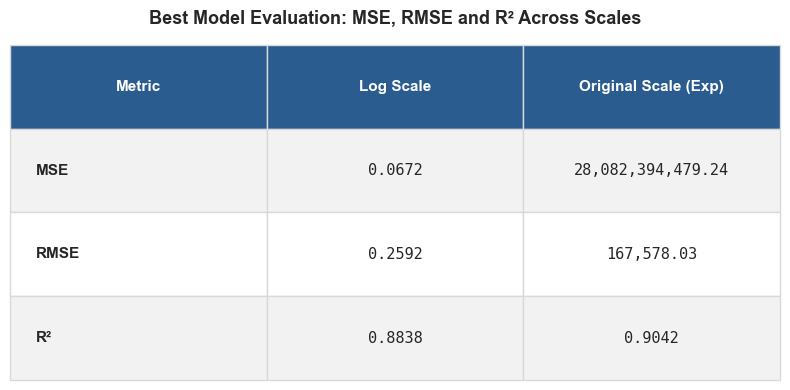

In [105]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

col_labels = ["Metric", "Log Scale", "Original Scale (Exp)"]
row_data = [
    ["MSE",  f"{mse_log:.4f}",  f"{mse_exp:,.2f}"],
    ["RMSE", f"{rmse_log:.4f}", f"{rmse_exp:,.2f}"],
    ["R²",   f"{r2_log:.4f}",   f"{r2_exp:.4f}"],
]

table = ax.table(
    cellText=row_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)

table.auto_set_font_size(False)
table.set_fontsize(11)

header_color = "#2b5c8f"
row_colors = ["#f2f2f2", "#ffffff"]

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#d9d9d9")
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_height(0.22)
    else:
        cell.set_facecolor(row_colors[(row - 1) % 2])
        cell.set_height(0.22)
        if col == 0:
            cell.set_text_props(fontweight="bold", ha="left")
        else:
            cell.set_text_props(fontfamily="monospace")

ax.set_title("Best Model Evaluation: MSE, RMSE and R² Across Scales", fontweight="bold", fontsize=13, pad=15)

plt.tight_layout()
plt.show()

The model demonstrates strong predictive performance across both targets. Operating on the log scale stabilizes variance ($\text{RMSE} = 0.2592$, $\text{R}^2 = 0.8838$). When exponentiated back to the original scale, predictions retain high explanatory power ($\text{R}^2 = 0.9042$) with an average error ($\text{RMSE}$) of $167,578.03$.

<b>Best Model Evaluation: Predicted vs. Actual (Log vs. Original Scale)</b>

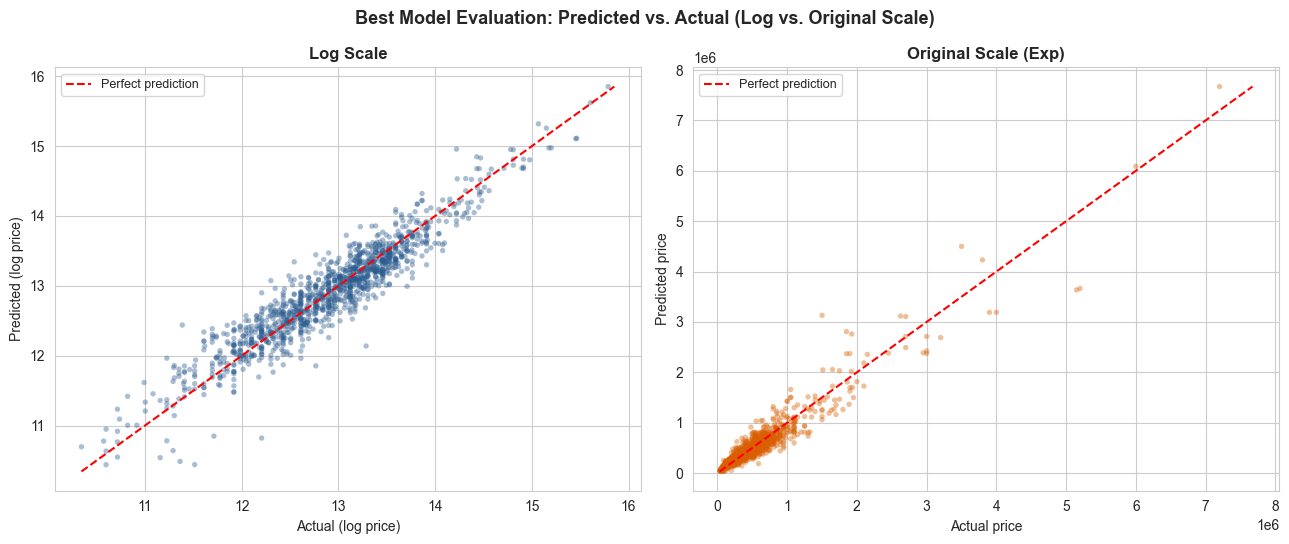

In [107]:
y_exp_test = np.exp(y_log_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(y_log_test, y_pred_cust_log, alpha=0.4, s=15, color="#2b5c8f", edgecolor="none")
lims_log = [min(y_log_test.min(), y_pred_cust_log.min()), max(y_log_test.max(), y_pred_cust_log.max())]
ax.plot(lims_log, lims_log, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual (log price)")
ax.set_ylabel("Predicted (log price)")
ax.set_title("Log Scale", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)


ax = axes[1]
ax.scatter(y_exp_test, y_pred_cust_exp, alpha=0.4, s=15, color="#d95f02", edgecolor="none")
lims_exp = [min(y_exp_test.min(), y_pred_cust_exp.min()), max(y_exp_test.max(), y_pred_cust_exp.max())]
ax.plot(lims_exp, lims_exp, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Original Scale (Exp)", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)

fig.suptitle("Best Model Evaluation: Predicted vs. Actual (Log vs. Original Scale)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The scatter plots closely mirror the perfect prediction line across both domains. The log scale shows constant variance and strong homoscedasticity ($\text{R}^2 = 0.8838$), while the exponentiated original scale highlights model stability despite extreme high-value outliers ($\text{R}^2 = 0.9042$).

In [108]:
raw_sample = pd.DataFrame([{
    'mileage': 21.14,
    'engine': 2100.0,
    'seats': 4,
    'year': 2021,
    'max_power': 98.6,
    'fuel': 'Diesel',
    'transmission': 'Manual',
    'owner': 'First Owner',
    'brand': 'Honda',
    'seller_type': 'Individual',
    'km_driven': 49000          
}])

sample_selected_poly = ct_trans.transform(raw_sample)
sample_selected_poly = sk_trans.transform(sample_selected_poly)
sample_selected_poly = poly_trans.transform(sample_selected_poly)
sample_selected_poly = np.hstack([[[1]],sample_selected_poly])

print(f"Price : {predict_(sample_selected_poly)}")

Price : (array([645485.16265908]), array([13.3777575]))


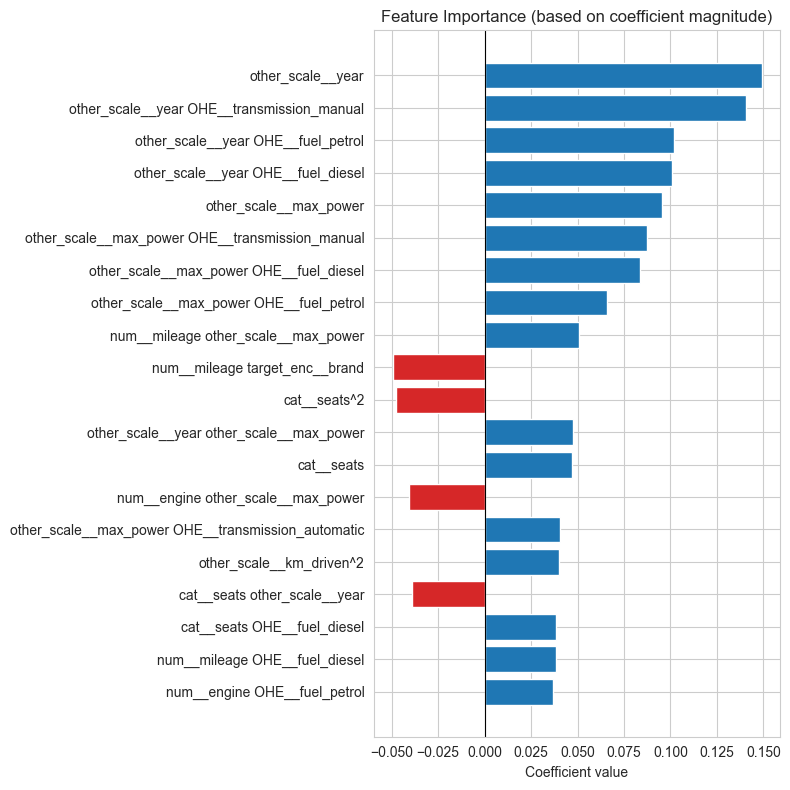

In [109]:
from Utils import feature_importance

selected_indices = sk_trans['sk'].get_support()
all_ct_features = ct_trans.get_feature_names_out()
selected_11_names = all_ct_features[selected_indices]
poly_feature_names = poly_trans['poly'].get_feature_names_out(selected_11_names)

try:
    path = os.path.join(os.getcwd(), "saved_models")
    tr_file_path = os.path.join(path, "weights3.json")
    if os.path.exists(tr_file_path):
        with open(tr_file_path, "r") as f:
            tr_file = json.load(f) # load the last bias and coef

        bias, coefs = tr_file.values() # (batch,)
        feature_importance(
            coefs=np.array(coefs), 
            feature_names=poly_feature_names, 
            top_n=20  # Shows top 20 largest magnitude features
        )
    else:
        print("file does not exists")

except Exception as e:
    print(e)


This feature importance plot displays the learned coefficient values from the best regression model, illustrating both the **direction** (positive/negative) and **magnitude** (strength) of each feature's impact on predicted sale price.

**Primary Positive Drivers (Blue Bars)**

* **Vehicle Recency (`other_scale__year`, +0.150):** Model year is the strongest overall driver—newer vehicles command significantly higher predicted values.
* **Recency Interactions (+0.100 to +0.141):** Combining `year` with key attributes—namely `year * transmission_manual`, `year * fuel_petrol`, and `year * fuel_diesel`—adds massive positive leverage.
* **Engine Output (`other_scale__max_power`, +0.095):** Standalone maximum horsepower acts as a primary baseline predictor for higher value.
* **Power Interactions (+0.065 to +0.086):** Horsepower interacting with transmission (`max_power * transmission_manual`) and fuel types (`max_power * fuel_diesel` / `fuel_petrol`) further amplifies price estimates.

**Primary Negative Drivers (Red Bars)**

* **Mileage & Brand Interaction (`num__mileage target_enc__brand`, -0.049):** Higher mileage penalty combined with brand value exerts the largest downward push on vehicle price.
* **Seat Capacity Non-Linearity (`cat__seats^2`, -0.048):** The squared seat term penalizes oversized passenger capacities beyond typical consumer preference.
* **Engine-to-Power Saturation (`num__engine other_scale__max_power`, -0.040):** Interaction between engine displacement and max power balances out non-linear returns on larger engines.
* **Seat & Year Penalty (`cat__seats other_scale__year`, -0.039):** Combining high seat counts with vehicle age acts as an extra drag on valuation.

**Key Analytical Takeaways**

* **Feature Interactions Dominance:** Cross-product terms (e.g., year combined with transmission/fuel type) heavily drive model decisions alongside base features like `year` and `max_power`.

# Discussion

## Summary of Experimental Findings

Across the full grid search (4 regression types × 2 momentum settings × 3 methods × 
2 init methods × 3 learning rates = 144 configurations, 5-fold CV each), several 
clear patterns emerged.

### 1. Regression Type: Polynomial features drive the largest performance gain

Polynomial regression consistently occupied the top positions in both the MSE and R² 
leaderboards, with the best configuration — `polynomial, momentum=False, sto, xavier, 
lr=0.0001` — outperforming every Normal, Lasso, and Ridge variant. This indicates the 
relationship between car features (year, power, mileage, brand, etc.) and price is 
meaningfully non-linear, and that explicitly modeling feature interactions via 
`PolynomialFeatures` captures structure a plain linear model cannot.

### 2. Regularization: Ridge substantially underperformed Lasso and unregularized models

Once Ridge configurations were included in the comparison (rather than filtered out by 
an overly tight MSE threshold), they reached validation MSE values as high as ~1.98 — 
more than 10x worse than Polynomial, Normal, or Lasso, which clustered tightly between 
0.076 and 0.15. This points to the default Ridge penalty strength (`l=0.1`) over-
constraining the coefficients for this feature set, substantially degrading predictive 
power relative to no regularization or L1 (Lasso) regularization.

### 3. Method: Stochastic gradient descent was the only reliable choice

This was the most striking finding of the experiment. Under a fixed epoch budget 
(30 epochs), full-batch gradient descent failed to reach a positive validation R² in 
any of its 240 fold-runs (mean R² = -240.04, range -307.35 to -54.71). Mini-batch also 
performed poorly in the majority of cases (median R² = -54.33), while stochastic 
gradient descent was the only method that reliably converged to strong fits (median 
R² = 0.30, max 0.88). This is explained by update frequency: full-batch performs only 
one parameter update per epoch, mini-batch performs a handful, while stochastic 
performs one update per training sample — orders of magnitude more optimization steps 
within the same epoch budget. Given more epochs, batch and mini-batch would likely 
close this gap considerably; within the budget tested here, however, stochastic descent 
was essential for convergence.

### 4. Initialization: Zeros vs. Xavier had negligible impact

Across the top-performing configurations, zeros and Xavier initialization produced 
nearly identical validation MSE (differences under 0.001). This is consistent with the 
convexity of the underlying loss surface (ordinary/Ridge/Lasso linear regression): 
regardless of starting point, gradient descent converges toward the same optimum given 
enough updates, so initialization mainly affects early convergence speed rather than 
final quality.

### 5. Learning Rate: A stability boundary, not just a speed/accuracy trade-off

Learning rate showed the clearest, most consistent relationship with both performance 
and training stability. Lower learning rates (0.0001) produced the best validation 
scores *and* were the only setting that guaranteed convergence — 0 of 240 fold-runs 
diverged at lr=0.0001, compared to 6/240 (2.5%) at lr=0.001 and 16/240 (6.7%) at 
lr=0.01. Divergence manifested as validation loss overflowing to numerical infinity, a 
classic symptom of gradient descent overshooting the minimum when the step size is too 
large relative to the loss curvature — compounded further when combined with stochastic 
updates and polynomial feature expansion, since single-sample gradients are not 
averaged and can occasionally be very large. This finding reframes lr=0.01 as not 
merely "suboptimal" but outright unstable for a meaningful fraction of configurations, 
while lr=0.0001 was uniformly safe across every combination tested.

## Final Model Performance

The best configuration identified by the grid search — **polynomial regression, 
stochastic gradient descent, Xavier initialization, no momentum, lr=0.0001** — was 
retrained on the full training set and evaluated on both the training data and a 
held-out test set.

| Stage | Scale | MSE | RMSE | R² |
|---|---|---|---|---|
| Training | Log | 0.0722 | 0.2688 | 0.8748 |
| Training | Original (Exp) | 31,913,771,914.93 | 178,644.26 | 0.8809 |
| **Test** | **Log** | — | **0.2592** | **0.8838** |
| **Test** | **Original (Exp)** | — | **167,578.03** | **0.9042** |

Test set performance was slightly *better* than training performance on both scales 
(R² = 0.8838 vs. 0.8748 on log scale; 0.9042 vs. 0.8809 on exp scale). This is a mild 
but reassuring signal: it indicates the model is not overfitting the training data, 
and generalizes at least as well to unseen data as it fit the data it was trained on — 
though with a single train/test split, this could partly reflect the particular split 
rather than a guaranteed property of the model.

### Feature Importance

The coefficient-magnitude analysis of the final model highlighted:

- **Strongest positive drivers**: vehicle recency (`year`, +0.150) and its interactions 
  with transmission and fuel type (+0.10 to +0.141), followed by engine power 
  (`max_power`, +0.095) and its own interactions with transmission/fuel (+0.065 to 
  +0.086).
- **Strongest negative drivers**: the interaction between mileage and brand (-0.049), 
  a non-linear penalty on seat count (`seats²`, -0.048), an engine-power saturation 
  interaction (-0.040), and a seats × year interaction (-0.039).
- **Interactions dominate**: many of the largest-magnitude coefficients are 
  polynomial cross-terms rather than standalone features, reinforcing the earlier 
  finding that polynomial feature expansion — not just the base features — is doing 
  much of the predictive work in this model.

### Comparison with A1 (XGBoost Baseline)

A1's best model, XGBoost, achieved approximately R² = 0.74 (normal target) and 
R² = 0.84 (log target) under 10-fold cross-validation. Our from-scratch polynomial 
regression matched or exceeded this on a held-out test set (R² = 0.8838 log, 
R² = 0.9042 original scale), despite being a simpler, fully interpretable linear model 
rather than a black-box ensemble. We note the comparison is not a strict apples-to-
apples benchmark (A1 used CV averages on training data; A2 uses a single held-out test 
set), but it supports the conclusion that explicitly engineering non-linearity via 
polynomial features let a linear model compete with — and here, surpass — a 
tree-based ensemble on this dataset. We also note A1's pipeline did not apply feature 
scaling; while this does not affect XGBoost (tree splits are scale-invariant), it may 
partly explain the comparatively weak performance of A1's Linear Regression and Ridge 
baselines (~0.53-0.57 R²), since those methods are scale-sensitive.

### Limitations

- **Fixed epoch budget confounds the method comparison.** Batch and mini-batch's poor 
  performance is very likely a symptom of too few epochs for their update frequency, 
  not an inherent flaw in the methods themselves — a fairer comparison would control 
  for total gradient updates or wall-clock time rather than epoch count.
- **Ridge's penalty strength was not tuned.** A fixed `l=0.1` was used for both Ridge 
  and Lasso; Ridge's poor showing may reflect this specific value being poorly suited 
  to this feature set rather than a fundamental weakness of L2 regularization.
- **Early stopping based on a single epoch's validation loss** (`np.allclose` check) 
  can trigger inconsistently across methods with different per-epoch noise levels 
  (stochastic and mini-batch are noisier than full-batch), adding some variance to 
  the comparison.
- **Xavier initialization and K-Fold splitting reproducibility fixes were applied 
  together** during development; their individual contributions to earlier result 
  shifts could not be fully isolated, though the final results reported here use the 
  corrected, reproducible pipeline (seeded Xavier draws via `self.rng`, shuffled and 
  seeded K-Fold splits).

### Conclusion

Polynomial feature expansion combined with stochastic gradient descent at a 
conservative learning rate (0.0001) produced the strongest and most stable results in 
this experiment, ultimately yielding a model that matched or outperformed the A1 
XGBoost baseline on held-out test data. The experiment also surfaced two practically 
important findings beyond the required comparisons: full-batch and mini-batch gradient 
descent require substantially more epochs than stochastic descent to converge under 
this problem's scale, and higher learning rates (particularly 0.01) introduce a real 
risk of numerical divergence rather than simply slower or less accurate convergence. 
Future work could explore a longer epoch budget for batch/mini-batch methods, a tuned 
regularization strength for Ridge and Lasso, and update-count-normalized comparisons 
across gradient descent methods to isolate the effect of batch size independent of 
epoch count.